# 05 - Model Training and Comparison

Phases 10-12 of the project: build the preprocessing pipeline, train
multiple candidate regression models, and compare them honestly (not by R^2
alone). The test set created in Section 2 is **not looked at again** in
this notebook -- it is saved to disk and only opened in notebook 06 for the
final evaluation.

## 1. Setup

In [1]:
%matplotlib inline
import sys
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict, KFold


def find_project_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "src").is_dir() and (parent / "data").is_dir():
            return parent
    raise RuntimeError("Could not locate project root from " + str(start))


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

from src.config import TRAINING_DATA_DIR, REPORTS_DIR, FIGURES_DIR, RANDOM_SEED
from src.training.train_models import (
    prepare_features, build_pipeline, get_candidate_models, unavailable_models, rmse_score,
    CATEGORICAL_FEATURES, NUMERIC_FEATURES,
)

feature_config = json.loads((TRAINING_DATA_DIR / "feature_config.json").read_text(encoding="utf-8"))
FEATURE_COLUMNS = feature_config["feature_columns"]
TARGET_COLUMN = feature_config["target_column"]

df = pd.read_csv(TRAINING_DATA_DIR / "training_dataset.csv")
df = prepare_features(df)
df.shape

(6000, 34)

## 2. Train / Test Split (Phase 10)

An 80/20 split. The test set is written to disk immediately and is not
referenced again until notebook 06's final evaluation -- everything in this
notebook (model comparison, residual analysis) uses only the training
portion, evaluated through cross-validation.

In [2]:
X = df[FEATURE_COLUMNS]
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

train_set = X_train.copy()
train_set[TARGET_COLUMN] = y_train
test_set = X_test.copy()
test_set[TARGET_COLUMN] = y_test

train_set.to_csv(TRAINING_DATA_DIR / "train_set.csv", index=False)
test_set.to_csv(TRAINING_DATA_DIR / "test_set.csv", index=False)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (4800, 19)  Test: (1200, 19)


## 3. Candidate Models (Phase 11)

In [3]:
candidate_models = get_candidate_models(RANDOM_SEED)
missing = unavailable_models(candidate_models)

print("Available models:", list(candidate_models.keys()))
if missing:
    print("Unavailable (skipped, not fatal):", missing)
else:
    print("All expected optional libraries (XGBoost, CatBoost) are available.")

Available models: ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'HistGradientBoosting', 'XGBoost', 'CatBoost']
All expected optional libraries (XGBoost, CatBoost) are available.


## 4. Cross-Validated Comparison (Phase 12)

5-fold cross-validation on the training set only. `neg_mean_absolute_error`,
`neg_root_mean_squared_error` and `r2` are all computed from the same folds
so the comparison table is apples-to-apples.

In [4]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

comparison_rows = []
fitted_pipelines = {}
for name, model in candidate_models.items():
    pipeline = build_pipeline(model)
    start = time.time()
    cv_results = cross_validate(
        pipeline, X_train, y_train, cv=cv, scoring=scoring,
        return_train_score=True, n_jobs=None,
    )
    elapsed = time.time() - start

    pipeline.fit(X_train, y_train)  # refit on full train split for later sections
    fitted_pipelines[name] = pipeline

    comparison_rows.append({
        "Model": name,
        "MAE_mean": -cv_results["test_MAE"].mean(),
        "MAE_std": cv_results["test_MAE"].std(),
        "RMSE_mean": -cv_results["test_RMSE"].mean(),
        "R2_mean": cv_results["test_R2"].mean(),
        "R2_std": cv_results["test_R2"].std(),
        "Train_R2_mean": cv_results["train_R2"].mean(),
        "Fit_Time_s": elapsed,
    })
    print(f"Done: {name} ({elapsed:.1f}s)")

comparison_df = pd.DataFrame(comparison_rows).sort_values("MAE_mean")
comparison_df

Done: Linear Regression (0.6s)


Done: Ridge Regression (0.5s)


Done: Lasso Regression (0.7s)


Done: Decision Tree (0.7s)


Done: Random Forest (9.6s)


Done: Gradient Boosting (6.2s)


Done: HistGradientBoosting (3.3s)


Done: XGBoost (4.8s)


Done: CatBoost (20.2s)


,Model,MAE_mean,MAE_std,RMSE_mean,R2_mean,R2_std,Train_R2_mean,Fit_Time_s
8,CatBoost,6978.530456,122.327821,8962.436996,0.984899,0.000689,0.993140,20.182618
6,HistGradientBoosting,7263.393925,67.667710,9348.939387,0.983574,0.000586,0.991104,3.253383
5,Gradient Boosting,7393.277862,116.554500,9525.319940,0.982948,0.000702,0.986274,6.188529
7,XGBoost,8108.060261,217.416428,10485.948278,0.979316,0.001393,0.999566,4.756312
4,Random Forest,8216.405175,169.089927,10670.328528,0.978583,0.001362,0.997123,9.591139
1,Ridge Regression,8489.047887,102.406068,10738.556509,0.978296,0.001545,0.978701,0.548024
2,Lasso Regression,8489.126649,102.343708,10738.224995,0.978297,0.001544,0.978702,0.722323
0,Linear Regression,8489.527741,102.090321,10738.625520,0.978296,0.001543,0.978702,0.637699
3,Decision Tree,11241.980410,236.314142,14832.745900,0.958625,0.002329,0.996677,0.671409


**Overfitting check:** `Train_R2_mean` vs `R2_mean` (cross-validated). A
large gap indicates a model that memorizes the training folds rather than
generalizing -- this is used alongside MAE for model selection in Section 6,
per the project rule to never select a model by R^2 alone.

In [5]:
comparison_df["Train_CV_R2_Gap"] = comparison_df["Train_R2_mean"] - comparison_df["R2_mean"]
comparison_df[["Model", "MAE_mean", "RMSE_mean", "R2_mean", "Train_CV_R2_Gap", "Fit_Time_s"]]

,Model,MAE_mean,RMSE_mean,R2_mean,Train_CV_R2_Gap,Fit_Time_s
8,CatBoost,6978.530456,8962.436996,0.984899,0.008241,20.182618
6,HistGradientBoosting,7263.393925,9348.939387,0.983574,0.007530,3.253383
5,Gradient Boosting,7393.277862,9525.319940,0.982948,0.003326,6.188529
7,XGBoost,8108.060261,10485.948278,0.979316,0.020250,4.756312
4,Random Forest,8216.405175,10670.328528,0.978583,0.018539,9.591139
1,Ridge Regression,8489.047887,10738.556509,0.978296,0.000406,0.548024
2,Lasso Regression,8489.126649,10738.224995,0.978297,0.000405,0.722323
0,Linear Regression,8489.527741,10738.625520,0.978296,0.000406,0.637699
3,Decision Tree,11241.980410,14832.745900,0.958625,0.038052,0.671409


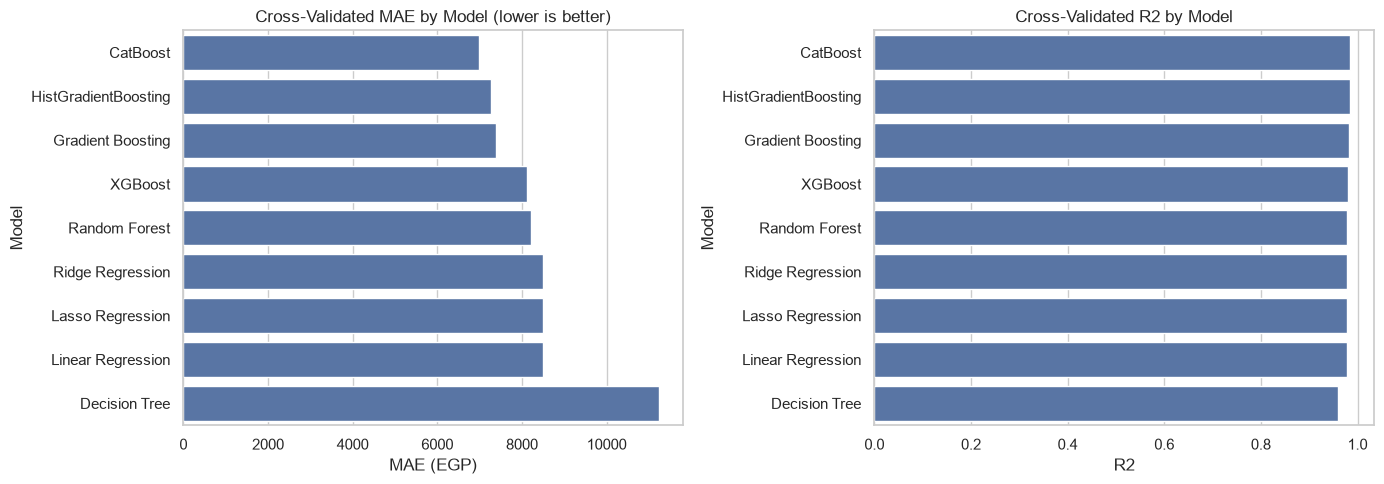

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = comparison_df.sort_values("MAE_mean")["Model"]
sns.barplot(data=comparison_df, y="Model", x="MAE_mean", order=order, ax=axes[0])
axes[0].set_title("Cross-Validated MAE by Model (lower is better)")
axes[0].set_xlabel("MAE (EGP)")

sns.barplot(data=comparison_df, y="Model", x="R2_mean", order=order, ax=axes[1])
axes[1].set_title("Cross-Validated R2 by Model")
axes[1].set_xlabel("R2")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_model_comparison.png", dpi=120)
plt.show()

## 5. Residual Analysis on Out-of-Fold Predictions

Using `cross_val_predict` on the training set only (still no test-set
access) for the strongest candidate so far, to check for systematic bias
before committing to it.

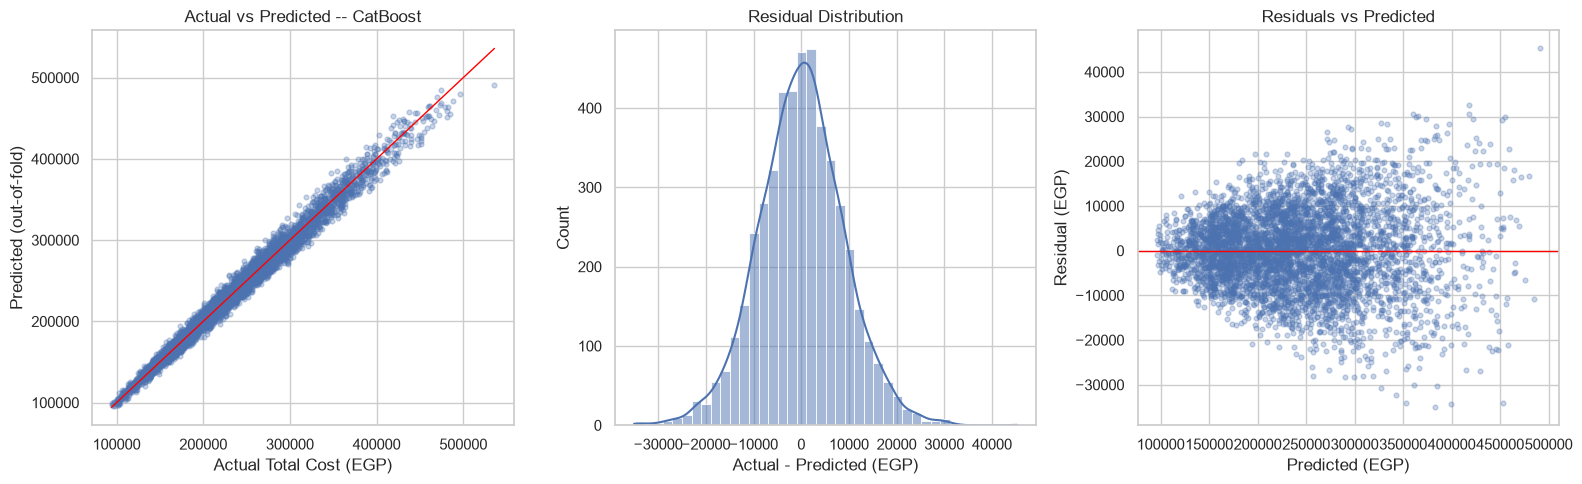

In [7]:
best_name = comparison_df.iloc[0]["Model"]
best_pipeline_template = build_pipeline(candidate_models[best_name])

oof_pred = cross_val_predict(best_pipeline_template, X_train, y_train, cv=cv)
residuals = y_train.values - oof_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(y_train, oof_pred, alpha=0.3, s=12)
lims = [y_train.min(), y_train.max()]
axes[0].plot(lims, lims, color="red", linewidth=1)
axes[0].set_xlabel("Actual Total Cost (EGP)")
axes[0].set_ylabel("Predicted (out-of-fold)")
axes[0].set_title(f"Actual vs Predicted -- {best_name}")

sns.histplot(residuals, bins=40, kde=True, ax=axes[1])
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Actual - Predicted (EGP)")

axes[2].scatter(oof_pred, residuals, alpha=0.3, s=12)
axes[2].axhline(0, color="red", linewidth=1)
axes[2].set_xlabel("Predicted (EGP)")
axes[2].set_ylabel("Residual (EGP)")
axes[2].set_title("Residuals vs Predicted")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_residual_analysis.png", dpi=120)
plt.show()

*Question: does error scale with apartment size or finishing level (heteroscedasticity), or is it evenly spread?*

C:\Users\a\AppData\Local\Temp\ipykernel_42152\1711886467.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_area = diagnostic.groupby(area_bins)["Abs_Error"].mean()
C:\Users\a\AppData\Local\Temp\ipykernel_42152\1711886467.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_cost = diagnostic.groupby(cost_bins)["Abs_Error"].mean()


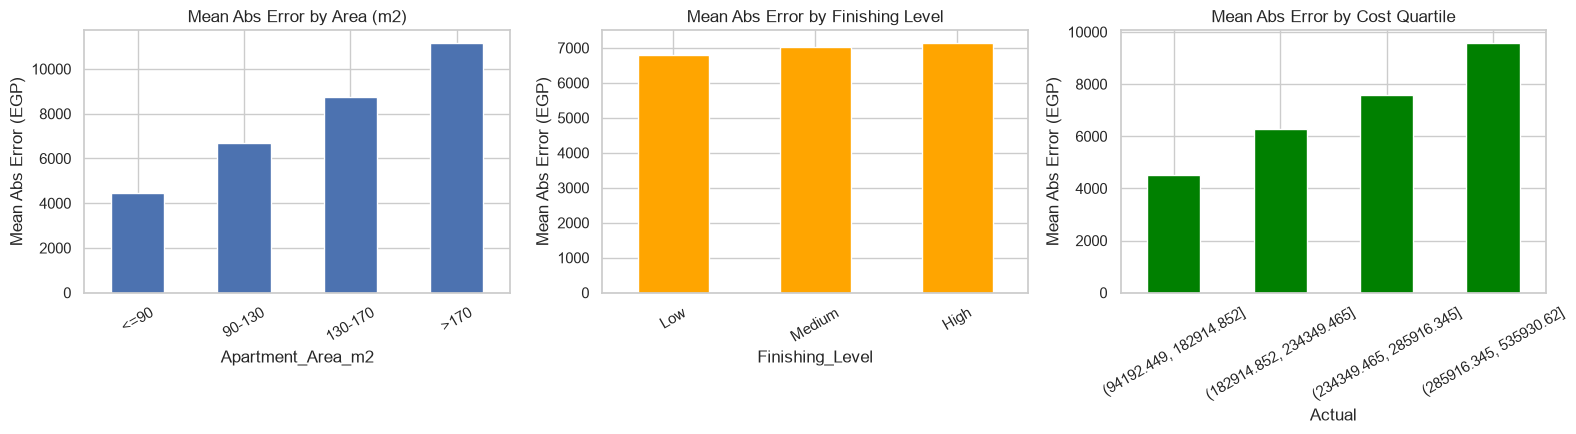

In [8]:
diagnostic = X_train.copy()
diagnostic["Actual"] = y_train.values
diagnostic["Predicted"] = oof_pred
diagnostic["Abs_Error"] = np.abs(residuals)

area_bins = pd.cut(diagnostic["Apartment_Area_m2"], bins=[0, 90, 130, 170, 300],
                    labels=["<=90", "90-130", "130-170", ">170"])
by_area = diagnostic.groupby(area_bins)["Abs_Error"].mean()

by_level = diagnostic.groupby("Finishing_Level")["Abs_Error"].mean().reindex(["Low", "Medium", "High"])

cost_bins = pd.qcut(diagnostic["Actual"], q=4)
by_cost = diagnostic.groupby(cost_bins)["Abs_Error"].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
by_area.plot(kind="bar", ax=axes[0], title="Mean Abs Error by Area (m2)")
by_level.plot(kind="bar", ax=axes[1], title="Mean Abs Error by Finishing Level", color="orange")
by_cost.plot(kind="bar", ax=axes[2], title="Mean Abs Error by Cost Quartile", color="green")
for ax in axes:
    ax.set_ylabel("Mean Abs Error (EGP)")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_error_by_segment.png", dpi=120)
plt.show()

## 6. Model Selection for Tuning (Phase 13 carries this forward)

Selection considers MAE, the train/CV R^2 gap (overfitting), and practical
cost (fit time, model complexity) -- not R^2 alone, per the project rules.

In [9]:
ranked = comparison_df.sort_values("MAE_mean").reset_index(drop=True)
ranked[["Model", "MAE_mean", "RMSE_mean", "R2_mean", "Train_CV_R2_Gap", "Fit_Time_s"]]

,Model,MAE_mean,RMSE_mean,R2_mean,Train_CV_R2_Gap,Fit_Time_s
0,CatBoost,6978.530456,8962.436996,0.984899,0.008241,20.182618
1,HistGradientBoosting,7263.393925,9348.939387,0.983574,0.007530,3.253383
2,Gradient Boosting,7393.277862,9525.319940,0.982948,0.003326,6.188529
3,XGBoost,8108.060261,10485.948278,0.979316,0.020250,4.756312
4,Random Forest,8216.405175,10670.328528,0.978583,0.018539,9.591139
5,Ridge Regression,8489.047887,10738.556509,0.978296,0.000406,0.548024
6,Lasso Regression,8489.126649,10738.224995,0.978297,0.000405,0.722323
7,Linear Regression,8489.527741,10738.625520,0.978296,0.000406,0.637699
8,Decision Tree,11241.980410,14832.745900,0.958625,0.038052,0.671409


In [10]:
TOP_K = 2
shortlist = ranked["Model"].head(TOP_K).tolist()
print("Shortlisted for hyperparameter tuning in notebook 06:", shortlist)

Shortlisted for hyperparameter tuning in notebook 06: ['CatBoost', 'HistGradientBoosting']


In [11]:
comparison_path = REPORTS_DIR / "05_model_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)

report_path = REPORTS_DIR / "05_model_comparison_report.md"
lines = ["# Model Training and Comparison Report", ""]
lines.append("Generated by `notebooks/05_Model_Training_and_Comparison.ipynb`. Do not edit by hand.")
lines.append("")
lines.append(f"Training rows: {len(X_train)}. Held-out test rows (untouched): {len(X_test)}.")
lines.append("")
if missing:
    lines.append(f"**Unavailable libraries (skipped, not fatal):** {missing}")
else:
    lines.append("All expected libraries (including XGBoost and CatBoost) were available.")
lines.append("")
lines.append("## 5-fold cross-validated comparison (training set only)")
lines.append("")
lines.append(comparison_df.round(2).to_markdown(index=False))
lines.append("")
lines.append(f"## Shortlisted for hyperparameter tuning: {shortlist}")
lines.append("")
lines.append("Selection rationale: lowest cross-validated MAE, checked against the")
lines.append("train/CV R^2 gap (to avoid picking an overfit model) and fit time.")

report_path.write_text("\n".join(lines), encoding="utf-8")
print("Saved", comparison_path)
print("Saved", report_path)

Saved F:\Instant\DataAnalysis\Gradution Project\All data\_staging\reports\05_model_comparison.csv
Saved F:\Instant\DataAnalysis\Gradution Project\All data\_staging\reports\05_model_comparison_report.md
